# 05 — Explainability: SHAP (Albania 2022)

Global and local explanations for the LightGBM model on the Albania 2022 cohort. LightGBM is fit fresh in this kernel — its Homebrew libomp is imported before scikit-learn (import-order fix), so the single-booster fit is OpenMP-safe and SHAP runs live.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS duplicate OpenMP guard
try:
    import lightgbm  # noqa: F401 - load its Homebrew libomp BEFORE sklearn's (import-order fix, avoids rc=-11)
except Exception:
    pass
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
import shap
from src.models.prepare import build_model_data, impute_median
from src.features.transformers import EngineeredFeatureBuilder
from src.models.registry import get_model
from src.explainability.shap_analysis import compute_shap_values, global_feature_importance

df = pd.read_parquet('../data/processed/alb_2022.parquet')
feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
data = build_model_data(df, feats, domain='math')
# engineered features (SES_COMPLETE, interactions, ...) built here for the
# final explanatory model (single fit on all data, so fit-on-all is fine)
X_eng = EngineeredFeatureBuilder().fit_transform(data.X)
(X,) = impute_median(X_eng); y = data.y.values
model = get_model('lightgbm'); model.fit(X, y, sample_weight=data.weights.values)
print('trained on', X.shape)

2026-07-02 14:45:47 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-07-02 14:45:47 [info     ] Feature selection complete     n_features=13


2026-07-02 14:45:47 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_countries=1 n_features=25 n_samples=6129 target_col=AT_RISK_MATH weights_normalized=False


trained on (6129, 33)


## 1. Global feature importance (mean |SHAP|)

In [3]:
shap_vals, names = compute_shap_values(model, X,
        X_background=X.sample(min(300, len(X)), random_state=42), max_samples=2000)
imp = global_feature_importance(shap_vals, names)
imp

2026-07-02 14:45:48 [info     ] Subsampling for SHAP           original=6129 sampled=2000


2026-07-02 14:45:48 [info     ] Using TreeSHAP                 model_type=LGBMClassifier


2026-07-02 14:45:48 [info     ] SHAP values computed           shape=(2000, 33)


,feature,mean_abs_shap,rank
0,ANXMAT,0.263395,1
1,HISCED,0.247934,2
2,HOMEPOS,0.239666,3
3,HISEI,0.187578,4
4,MATERIAL_DEFICIT,0.175356,5
5,BELONG,0.167147,6
6,ESCS,0.117253,7
7,GRADE_x_SES,0.108718,8
8,TEACHSUP,0.106932,9
9,DIGITAL_READINESS,0.098402,10


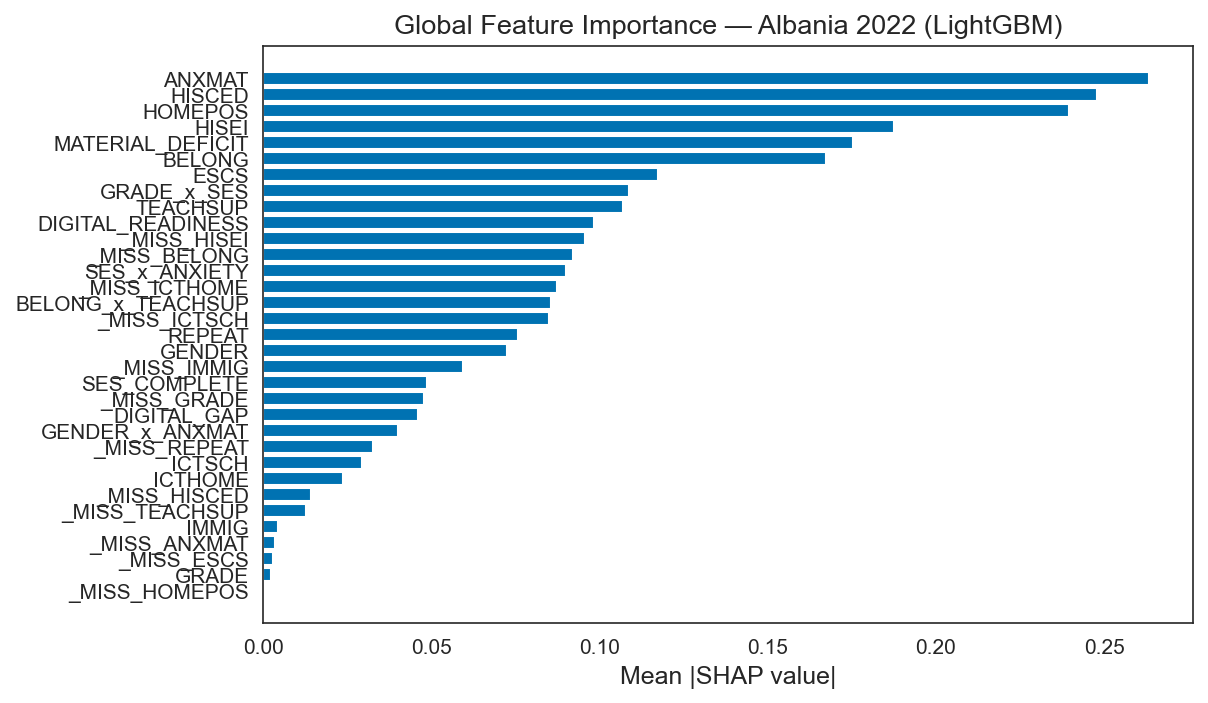

In [4]:
from src.visualization.style import apply_publication_style
apply_publication_style()
imp_s = imp.sort_values('mean_abs_shap')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(imp_s['feature'], imp_s['mean_abs_shap'], color='#0072B2')
ax.set_xlabel('Mean |SHAP value|'); ax.set_title('Global Feature Importance — Albania 2022 (LightGBM)')
plt.show()

**Reading:** `ANXMAT` (math anxiety) dominates, followed by parental education and home resources (`HISCED`, `HOMEPOS`, `HISEI`, `MATERIAL_DEFICIT`) and school belonging (`BELONG`). Immigration status and grade deviation contribute almost nothing.

## 2. SHAP beeswarm — direction of effects

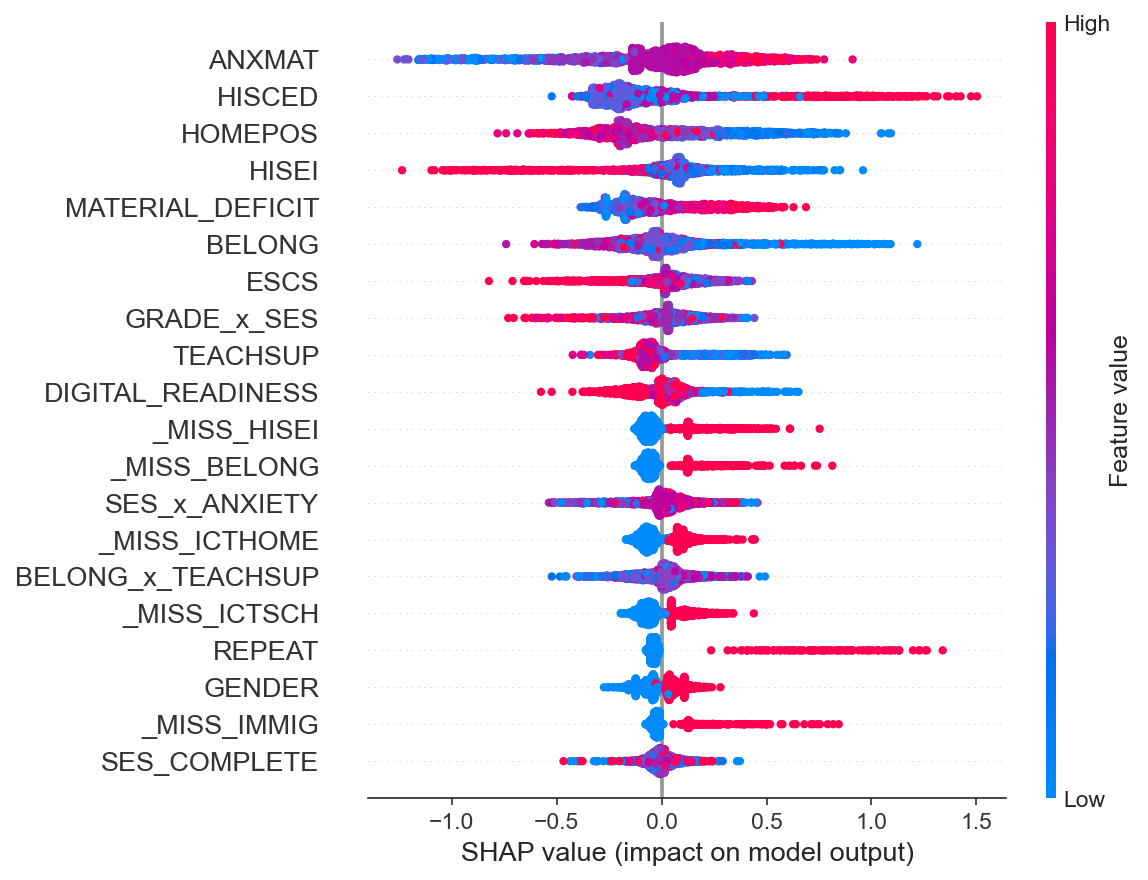

In [5]:
X_s = X.sample(min(2000, len(X)), random_state=42).reset_index(drop=True)
shap.summary_plot(shap_vals, X_s[names], show=True, plot_size=(8,6))

## 3. SHAP dependence — does SES moderate math anxiety?

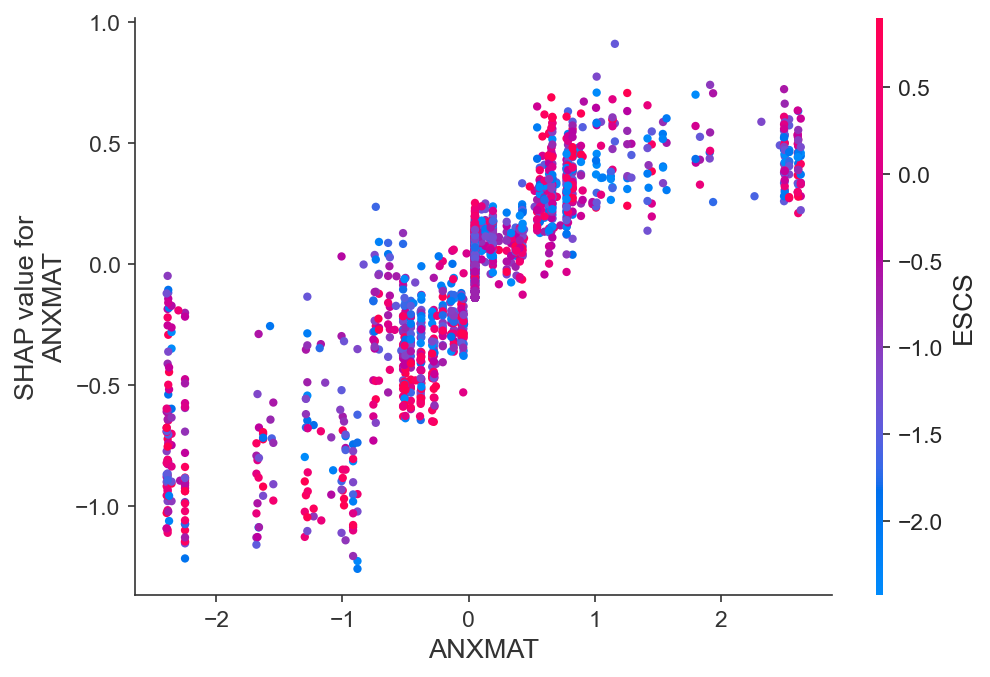

In [6]:
if 'ANXMAT' in names and 'ESCS' in names:
    shap.dependence_plot('ANXMAT', shap_vals, X_s[names], interaction_index='ESCS', show=True)

**Interpretation:** higher math anxiety pushes predictions toward at-risk; the colouring shows whether socioeconomic status buffers or amplifies that effect — a policy-relevant interaction.

## Conclusions & Interpretation

- **What drives predicted risk (mean |SHAP|):** `ANXMAT` (math anxiety) > `MATERIAL_DEFICIT` > `HISCED` / `HOMEPOS` / `HISEI` (parental education, home & material resources) > `BELONG` > `ESCS`. Math anxiety and material deprivation dominate.
- **Negligible:** immigration status and grade deviation add almost nothing — Albania's risk is a resources-and-affect story, not a migration one.
- **Interaction:** the ANXMAT × ESCS dependence indicates whether socioeconomic status buffers anxiety's effect — directly policy-relevant.
- **Policy read:** interventions targeting math anxiety and material support for low-resource students hit the highest-leverage factors. SHAP explains the *model* — associational, not causal.
- **Caveat:** explanations are for the single all-data CatBoost fit; per-fold stability and per-country SHAP comparison come in Phase 6+.